In [84]:
import pandas as pd
import numpy as np
import multiprocessing as mp
np.random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, MultiTaskLassoCV, RidgeCV, MultiTaskElasticNetCV, BayesianRidge, Ridge, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.base import RegressorMixin
import shap

import causalml
from causalml.metrics import plot_gain, plot_qini, qini_score
from causalml.dataset import synthetic_data
from causalml.inference.tree import plot_dist_tree_leaves_values, get_tree_leaves_mask
from causalml.inference.tree import CausalRandomForestRegressor, CausalTreeRegressor
from causalml.inference.tree.utils import timeit

import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'

In [85]:
import importlib
for libname in ["causalml", "shap"]:
    print(f"{libname}: {importlib.metadata.version(libname)}")



causalml: 0.15.1
shap: 0.46.0


In [104]:
"""
Treatments = Different ports Atlantic/Indian
outcome = y (target)
Confounders = x (Sediment, metals, etc)
"""




X_train = pd.read_csv("Nephytyidae/X_train_fauna.csv",
        sep=",",
        encoding="utf-8")
y_train = pd.read_csv("Nephytyidae/y_train_fauna.csv",
        sep=",",
        encoding="utf-8")
X_test = pd.read_csv("Nephytyidae/X_test_fauna.csv",
        sep=",",
        encoding="utf-8")
y_test = pd.read_csv("Nephytyidae/y_test_fauna.csv",
        sep=",",
        encoding="utf-8")

fauna = pd.read_csv("Nephytyidae/fauna.csv",
        sep=",",
        encoding="utf-8")
Nephtyidae = fauna.loc[:,"Nephtyidae"]
fauna = fauna.drop(columns=['Year','Nephtyidae','Location','Station','Latitude','Longitude','Station(Newnumber)'])
treatment = fauna["Port"].isin(["Cape Town", "Port Elizabeth" "Mossel Bay"]).astype(int)
fauna=fauna.drop(columns="Port")
fauna = fauna.loc[:,"Totalorganiccontent":"Zn"]
X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(fauna, Nephtyidae, treatment, test_size=0.2, random_state=42)
feature_names = fauna.columns

In [105]:
# model = RandomForestRegressor(max_depth= None, max_features= 'sqrt', min_samples_leaf= 4, min_samples_split= 2, n_estimators= 100, random_state=42)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

# rf = RandomForestRegressor(random_state=42)

# param_grid = {
#             'n_estimators': [200, 250, 300],
#             'max_depth': [None, 10, 20, 30],
#             'min_samples_split': [2, 5, 10],
#             'min_samples_leaf': [1, 2, 4],
#             'max_features': ['auto', 'sqrt', 'log2']
#         }

# grid_search = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',  
#     cv=5,
#     n_jobs=-1,
#     verbose=0
# )

# grid_search.fit(X_train, y_train)

# print("Best parameters found: ", grid_search.best_params_)
# print("Best score: ", grid_search.best_score_)

# y_pred = grid_search.best_estimator_.predict(X_test)
# model = grid_search.best_estimator_

# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)


# print("\n Random Forest regressor")
# print(f"Mean Absolute Error (MAE): {mae:.3f}")
# print(f"Mean Squared Error (MSE): {mse:.3f}")
# print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
# print(f"R-squared (R2): {r2:.3f}")

In [106]:


# explainer = shap.TreeExplainer(model, X_train)

# shap_values = explainer(X_test, check_additivity=False)

In [107]:
X_train

,Totalorganiccontent,Sand,Al,Fe,As,Ba,Be,Cd,Co,Cu,Cr,Mn,Hg,Ni,Pb,V,Zn
228,0.246239,91.779253,7.2603,6.36300,1.694,20.706,0.18880,0.036700,1.857,8.480,13.1644,42.490,0.016000,2.8785,3.690,11.1247,17.278200
78,6.382258,33.018868,25.0000,23.80000,28.400,853.000,0.93590,2.648000,30.375,3010.000,214.5000,174.750,3.304000,65.2500,996.000,48.7050,2650.000000
90,0.489400,88.382838,8.3560,7.46660,5.100,33.000,0.15760,0.079050,4.488,12.000,24.0000,89.000,0.035000,5.0150,10.925,14.4500,33.000000
16,9.617410,5.609284,45.0838,30.86010,16.700,265.692,1.31434,0.976378,8.704,220.293,71.5930,194.501,0.332843,22.6980,109.000,59.3000,321.000000
66,2.584000,3.154806,25.3886,26.85550,8.175,88.736,0.56100,0.064800,10.900,52.957,268.7710,369.441,0.030200,33.3980,15.120,46.6940,69.210000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,4.891435,22.082192,37.6000,27.80000,29.800,319.000,1.24190,0.772000,11.475,311.000,75.0000,162.000,0.333000,24.1500,151.000,53.8050,387.000000
106,4.262500,4.545455,33.6719,35.04165,9.840,176.000,1.62200,0.571600,9.740,67.531,74.5200,272.985,0.104000,23.1000,63.119,66.4000,143.923955
270,1.721705,44.703001,27.4248,26.41100,8.760,74.352,0.46020,0.053500,12.360,25.410,117.9000,424.280,0.014800,23.2410,11.871,46.7910,75.631500
348,1.531600,31.159420,51.4105,54.37950,10.965,99.000,0.90420,0.091500,22.444,58.900,460.1520,614.610,0.034600,62.8000,20.075,94.8942,78.500000


In [108]:
# new = pd.concat([fauna["Port"].isin(["Cape Town", "Mossel Bay"]),fauna], axis=1
#                 )
# new.to_csv('Nephytyidae/sedimentData.csv', index=False)

feature_names
# treatment_train
# shap.summary_plot(shap_values, X_test, show=False, feature_names=X_train.columns)

Index(['Totalorganiccontent', 'Sand', 'Al', 'Fe', 'As', 'Ba', 'Be', 'Cd', 'Co',
       'Cu', 'Cr', 'Mn', 'Hg', 'Ni', 'Pb', 'V', 'Zn'],
      dtype='object')

In [109]:
# 
# shap.force_plot(shap_values[0])

In [110]:
causal_forest = CausalRandomForestRegressor(criterion="causal_mse",
                                    min_samples_leaf=200,
                                    control_name=0,
                                    n_estimators=50,
                                    n_jobs=mp.cpu_count() - 1
                                )
causal_forest.fit(X=X_train, y=y_train, treatment=treatment_train)

# Estimate the treatment effect on the test data
# treatment_effects = causal_forest.predict(X_test.values, treatment=1) - causal_forest.predict(X_test.values, treatment=0)

df_importances = pd.DataFrame({'forest': causal_forest.feature_importances_,
                               'feature': feature_names
                              })
forest_std = np.std([tree.feature_importances_ for tree in causal_forest.estimators_], axis=0)

print(X_train.shape, y_train.shape, treatment_train.shape)
print(causal_forest.feature_importances_)  # Should be an array of feature importances
print(forest_std) 
treatment_effects = causal_forest.predict(X_test)

# `treatment_effects` will contain the estimated ITE for each observation
print(treatment_effects[:5]) 
# fig, ax = plt.subplots()
# df_importances['forest'].plot.bar(yerr=forest_std, ax=ax)
# ax.set_title("Causal Forest feature importances")
# ax.set_ylabel("Mean decrease in impurity")
# ax.set_xticklabels(feature_names, rotation=45)
# plt.show()


(280, 17) (280,) (280,)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[-5.95506521 -5.95506521 -5.95506521 -5.95506521 -5.95506521]


In [ ]:
treatment_effects.shape, X_test.columns.shape

((70,), (17,))

In [111]:
treatment_effect_by_feature = pd.DataFrame({
    'feature': X_test.columns,
    'treatment_effect': treatment_effects
})
sns.boxplot(x='feature', y='treatment_effect', data=treatment_effect_by_feature)
plt.title('Heterogeneous Treatment Effects by Feature')
plt.show()

ValueError: All arrays must be of the same length

In [113]:
# crforest = CausalRandomForestRegressor(criterion="causal_mse",
#                                   min_samples_leaf=200,
#                                   control_name=0,
#                                   n_estimators=50,
#                                   n_jobs=mp.cpu_count() - 1)
# crforest.fit(X=X_train, y=y_train, treatment=treatment_train)

KeyError: 'tree'

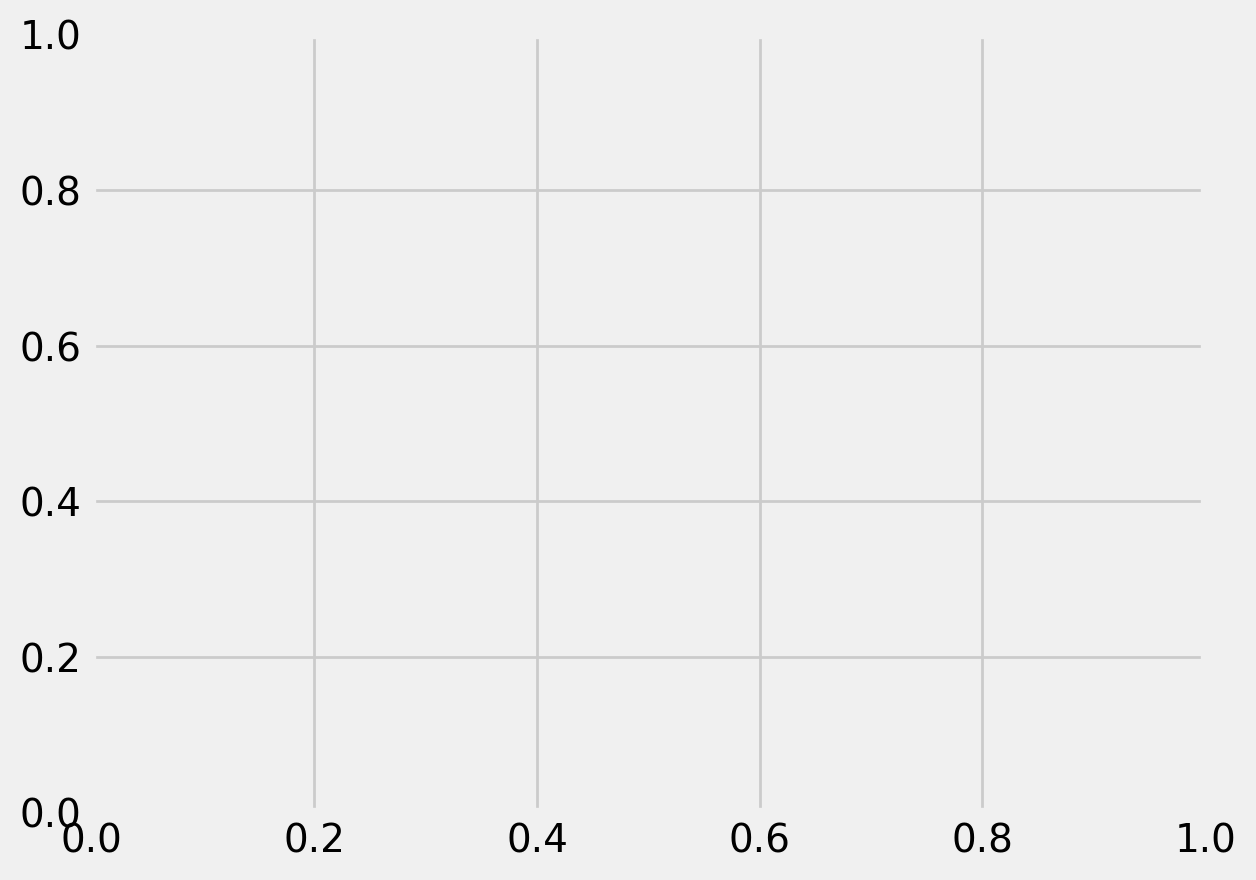

In [114]:
df_importances = pd.DataFrame({'forest': causal_forest.feature_importances_,
                               'feature': feature_names
                              })
forest_std = np.std([tree.feature_importances_ for tree in causal_forest.estimators_], axis=0)

fig, ax = plt.subplots()
df_importances['tree'].plot.bar(ax=ax)
ax.set_title("Causal Tree feature importances")
ax.set_ylabel("Mean decrease in impurity")
ax.set_xticklabels(feature_names, rotation=45)
plt.show()

fig, ax = plt.subplots()
df_importances['forest'].plot.bar(yerr=forest_std, ax=ax)
ax.set_title("Causal Forest feature importances")
ax.set_ylabel("Mean decrease in impurity")
ax.set_xticklabels(feature_names, rotation=45)
plt.show()



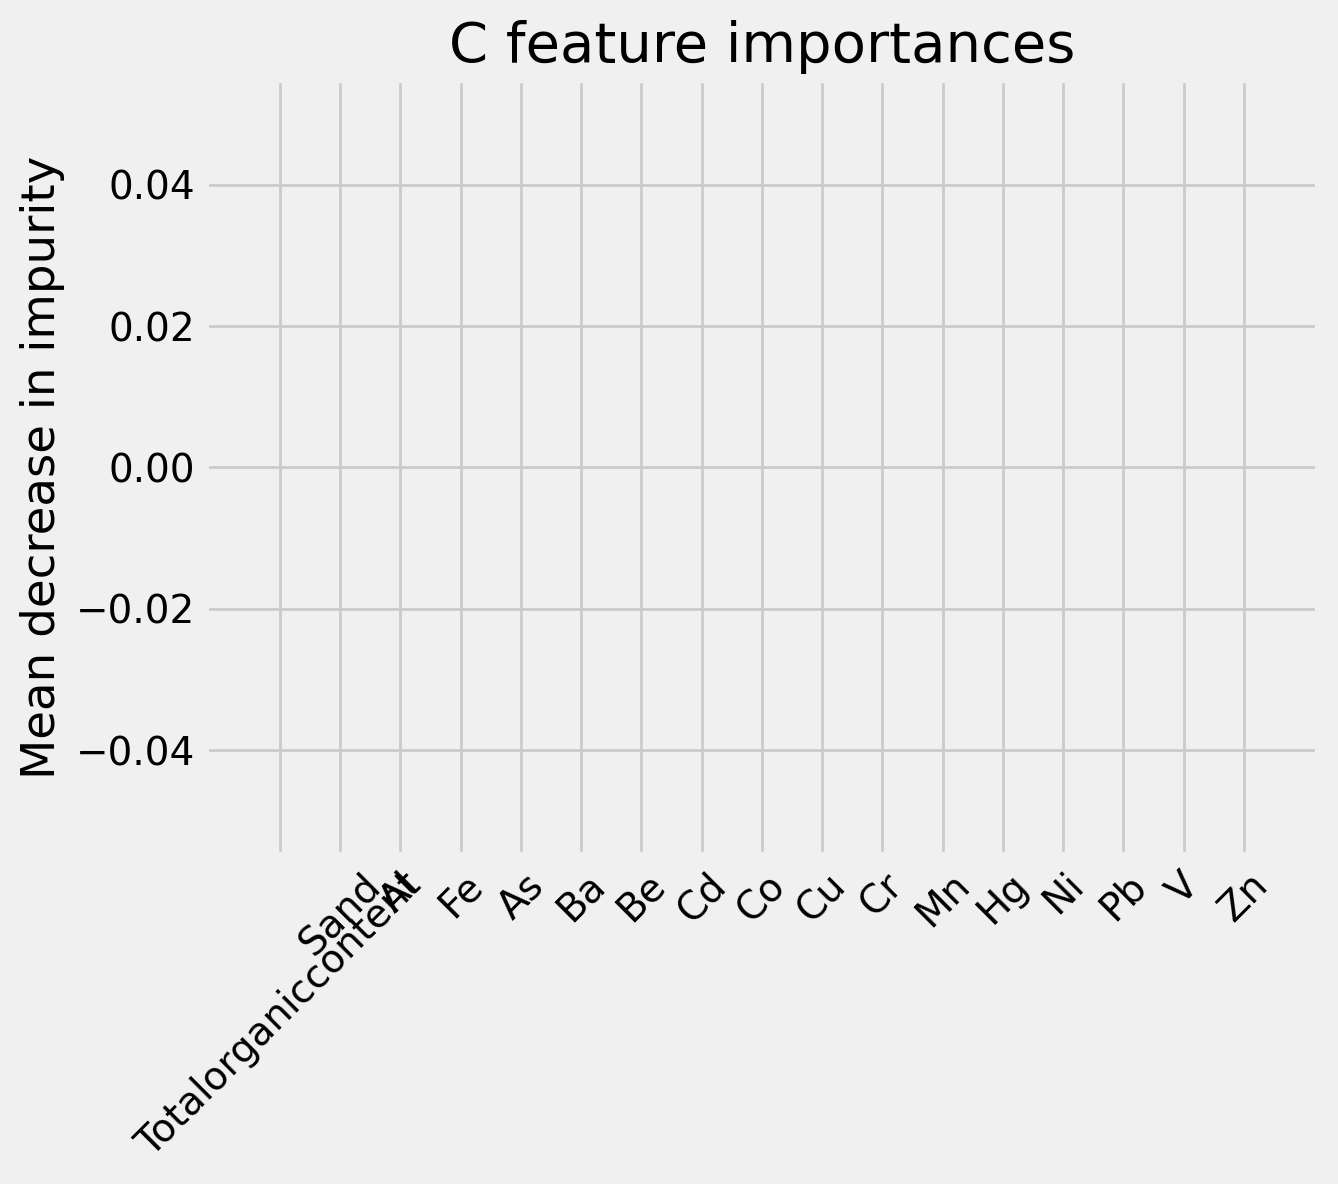

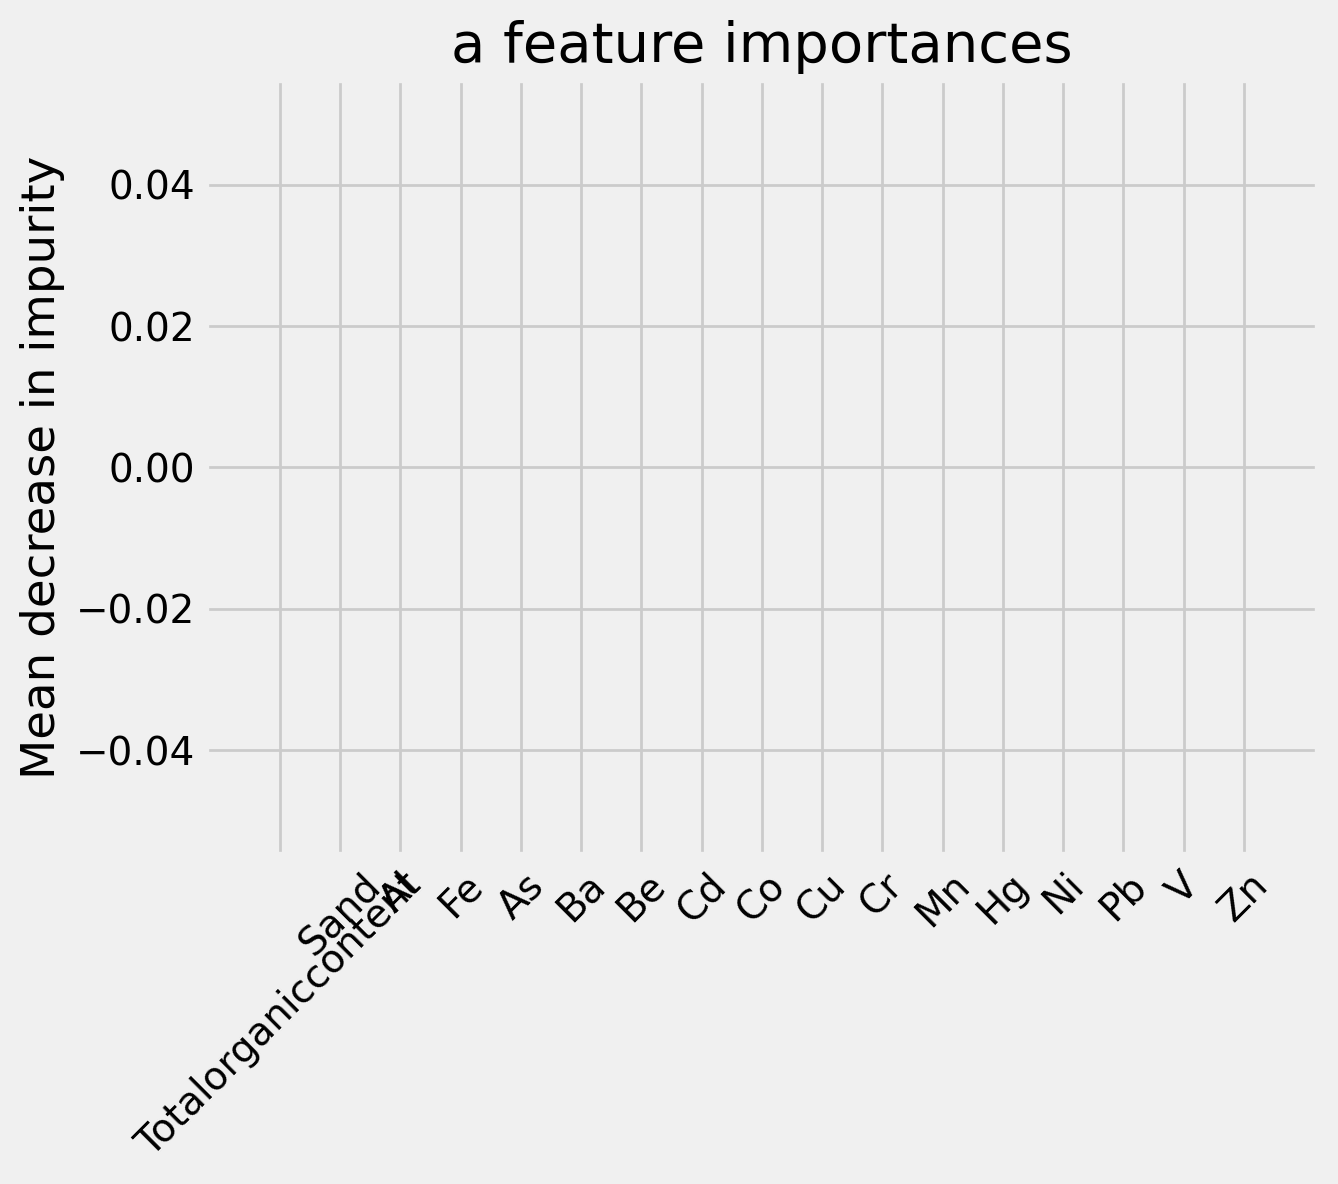

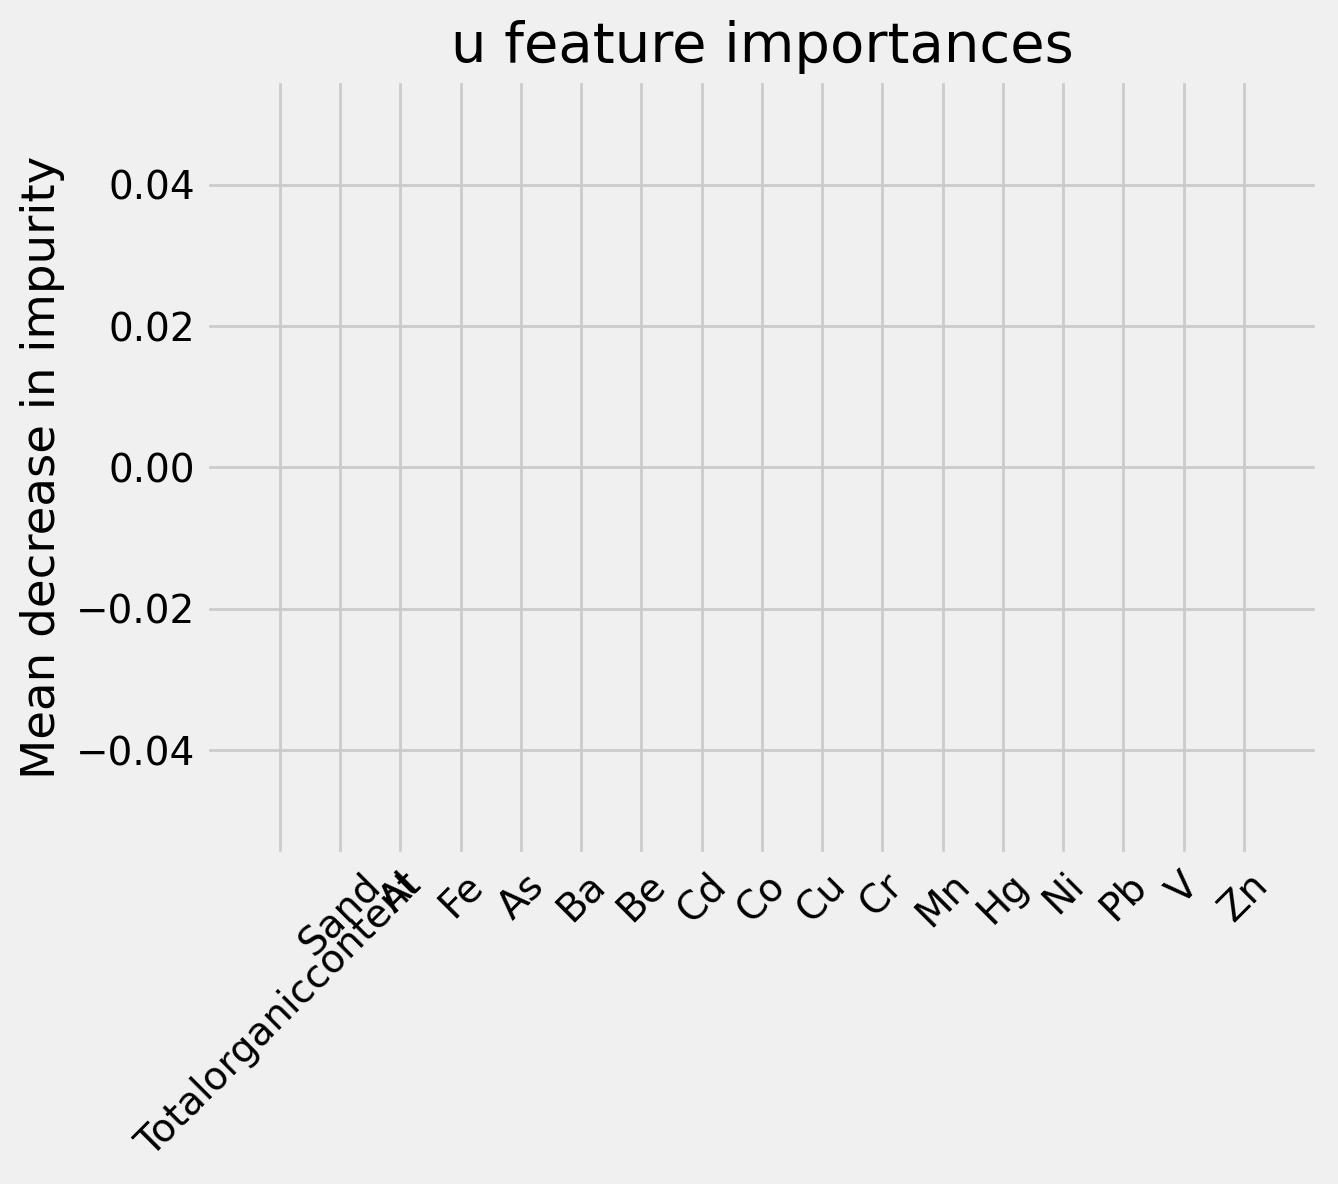

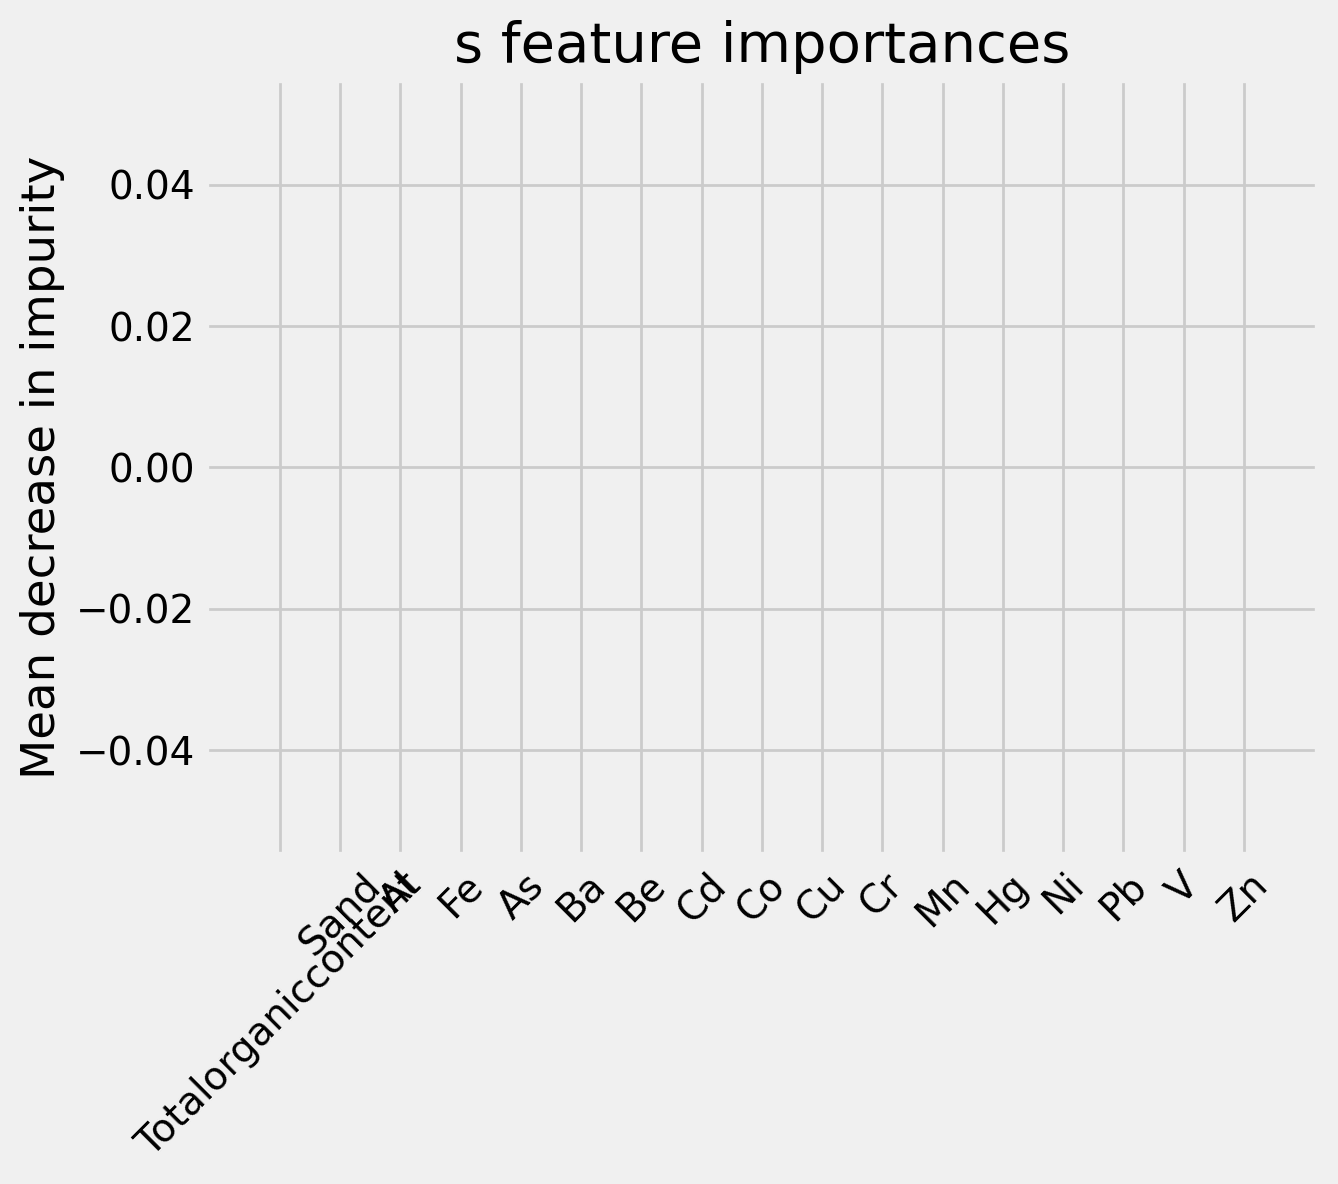

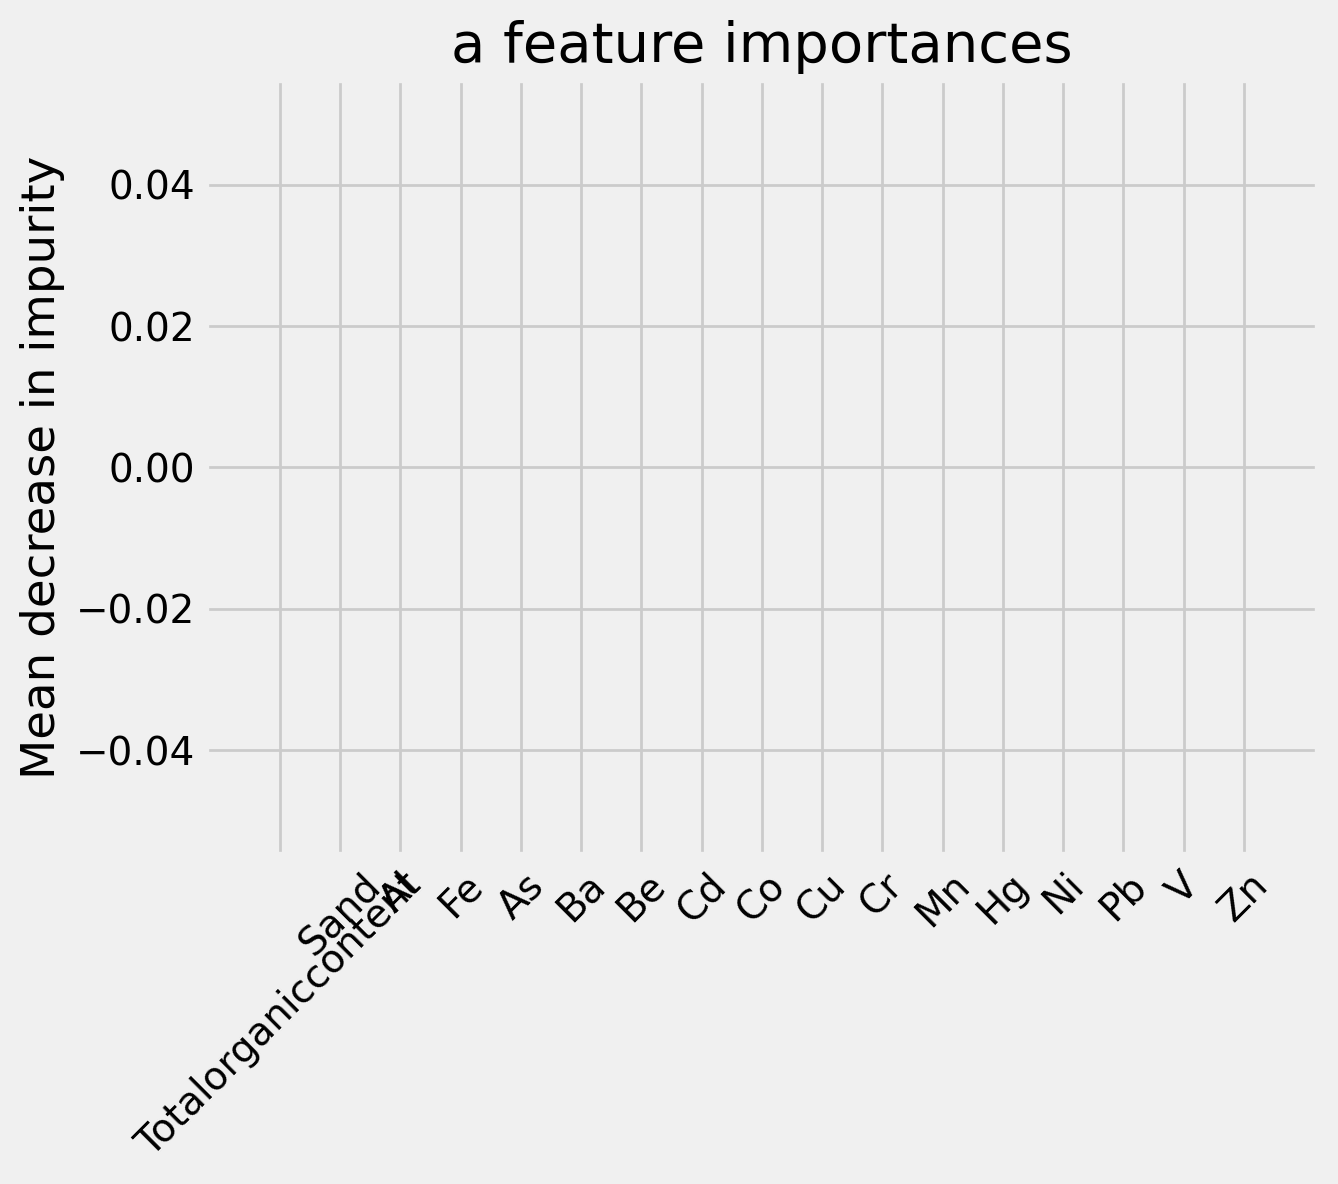

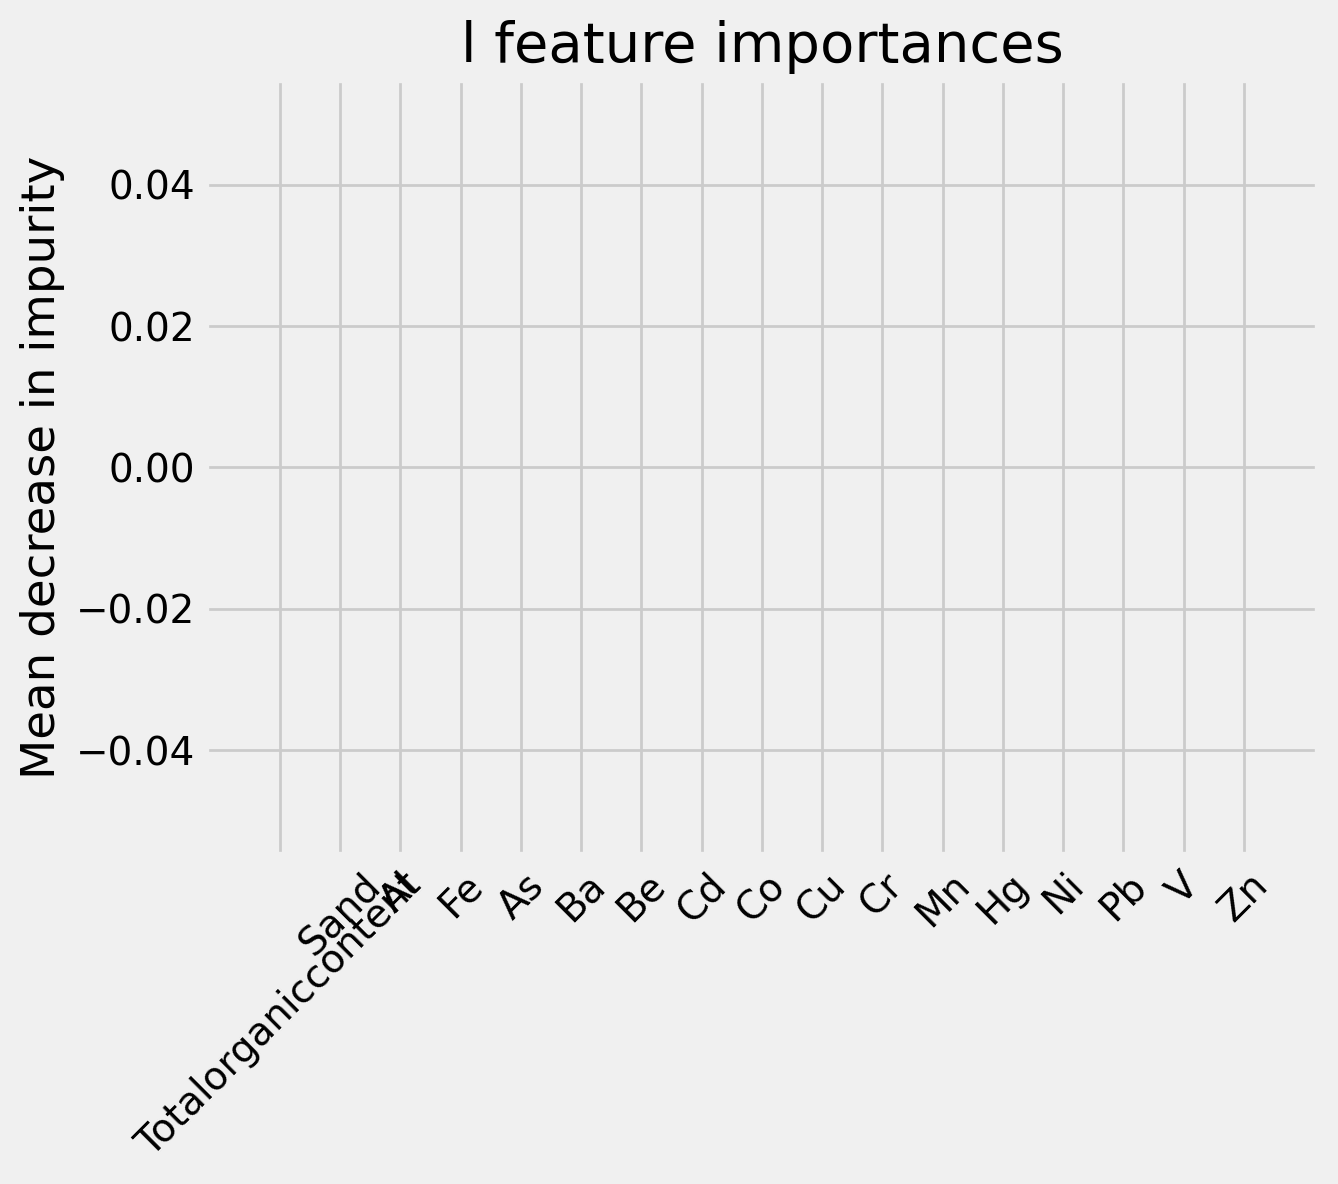

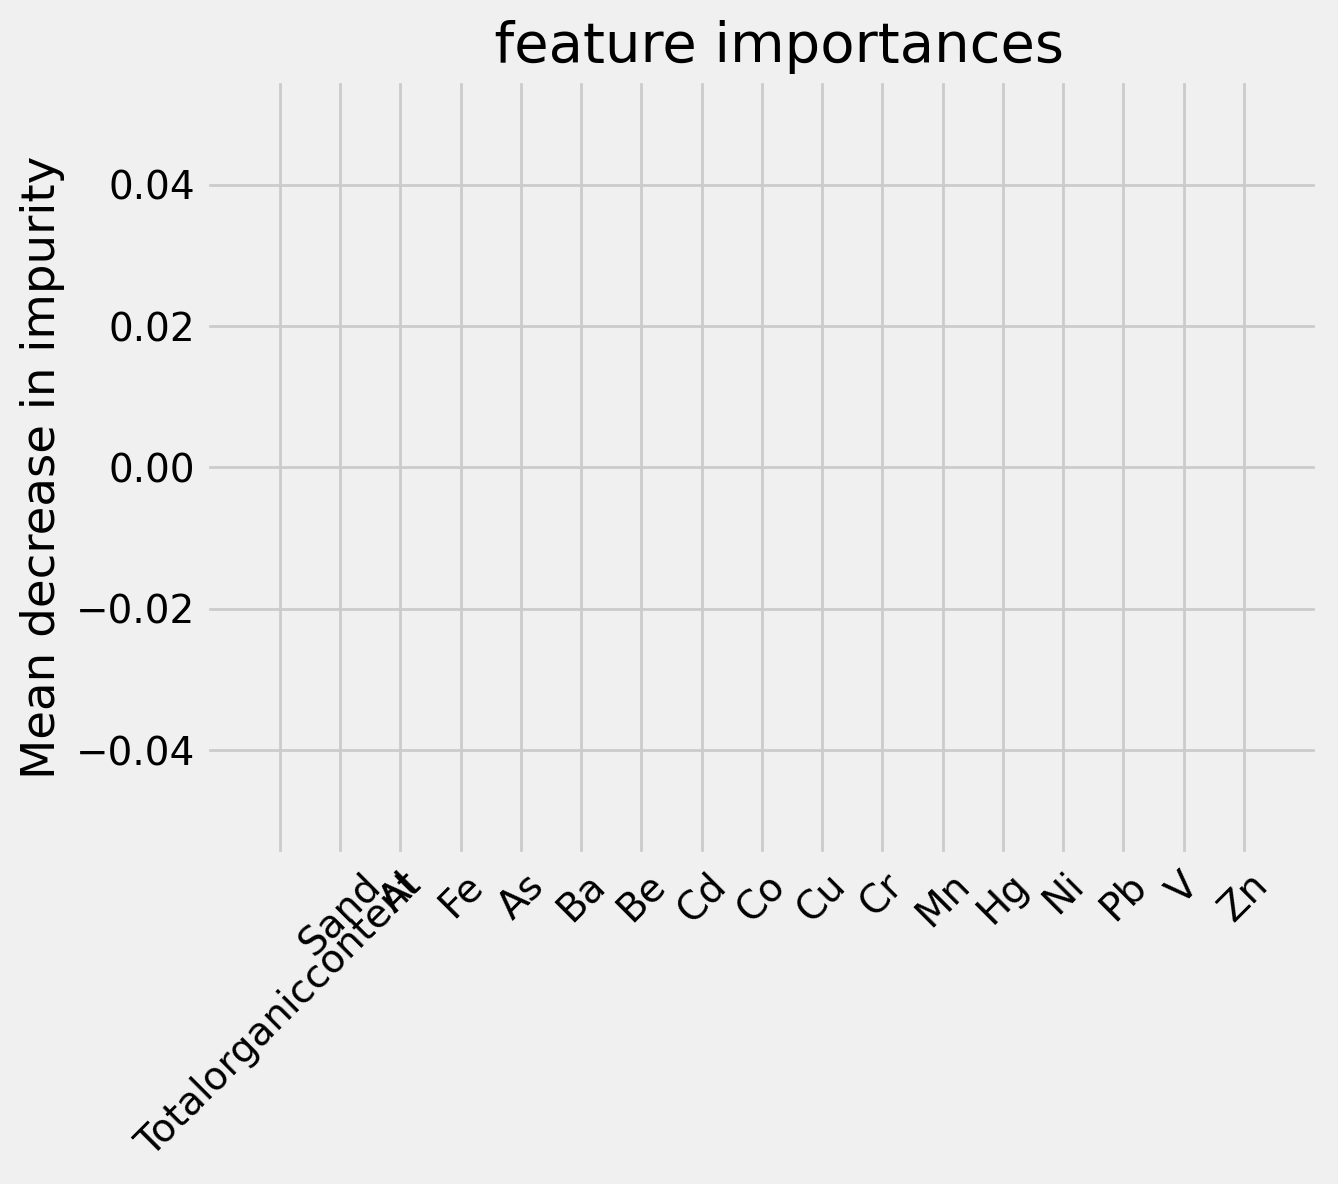

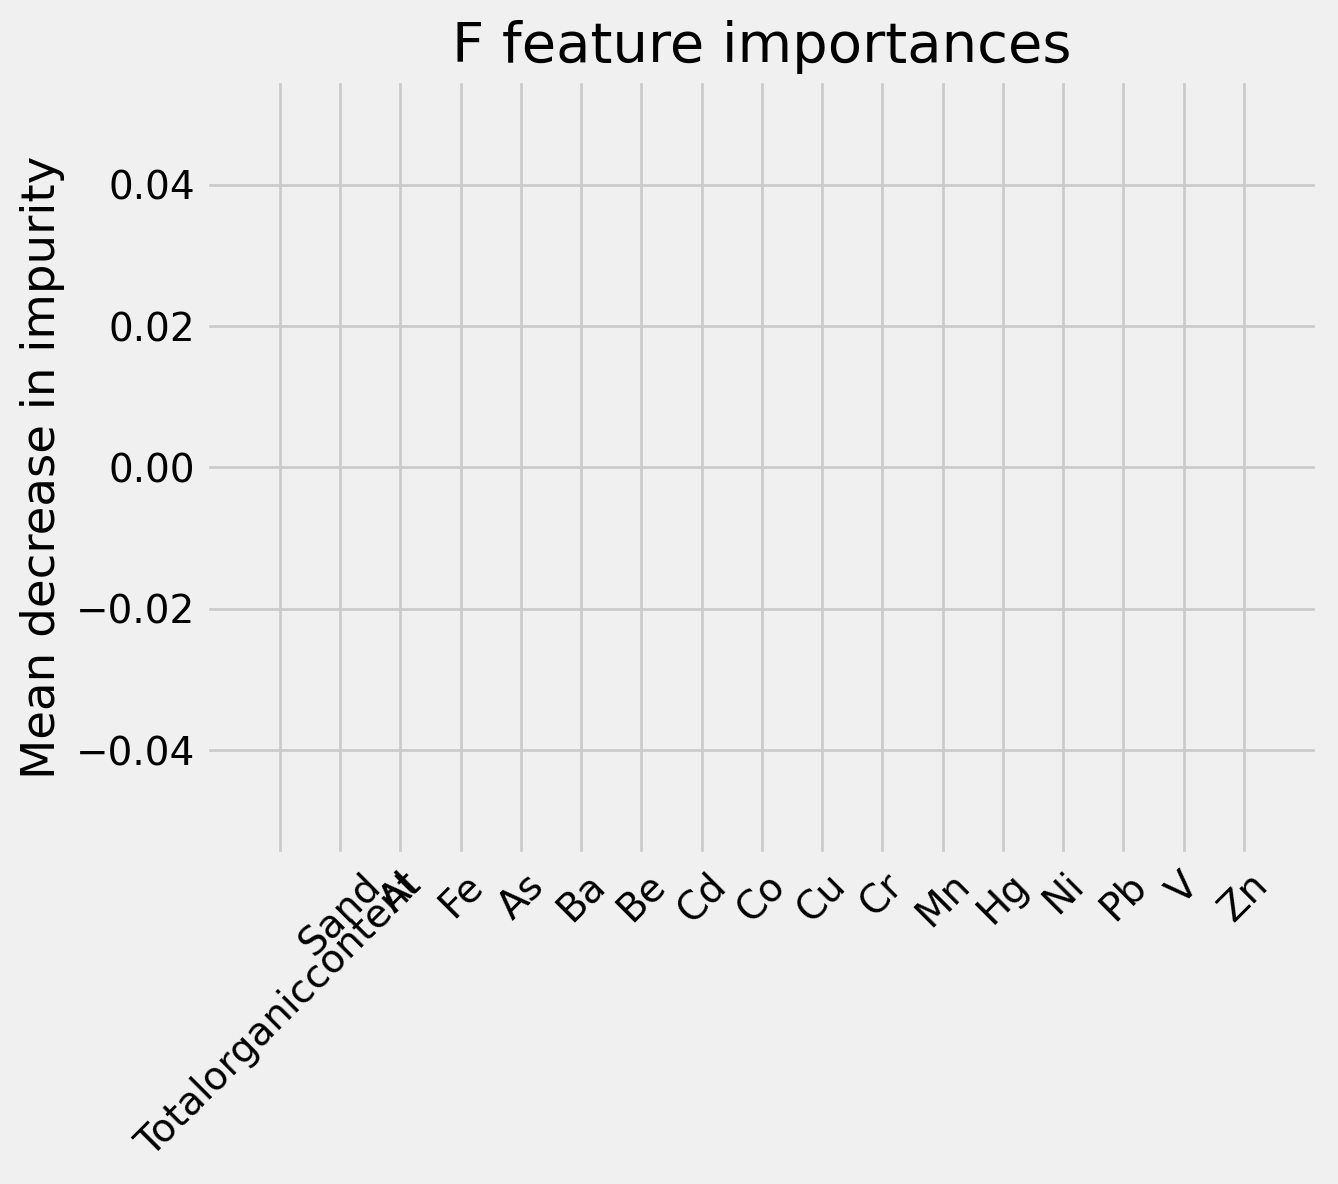

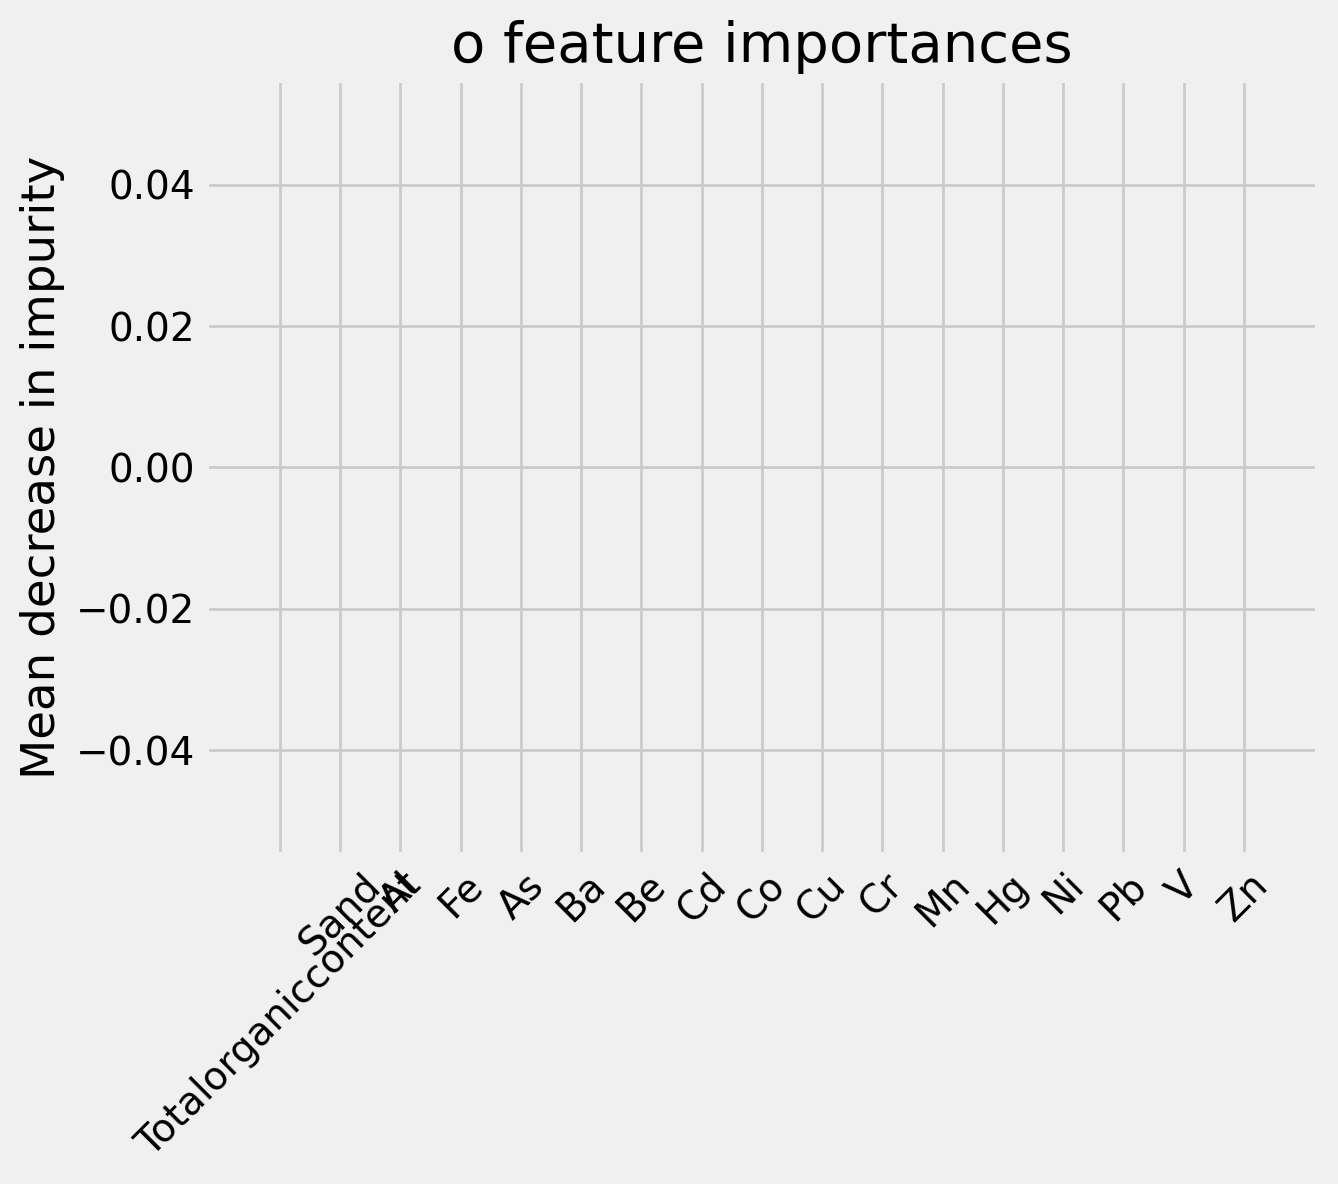

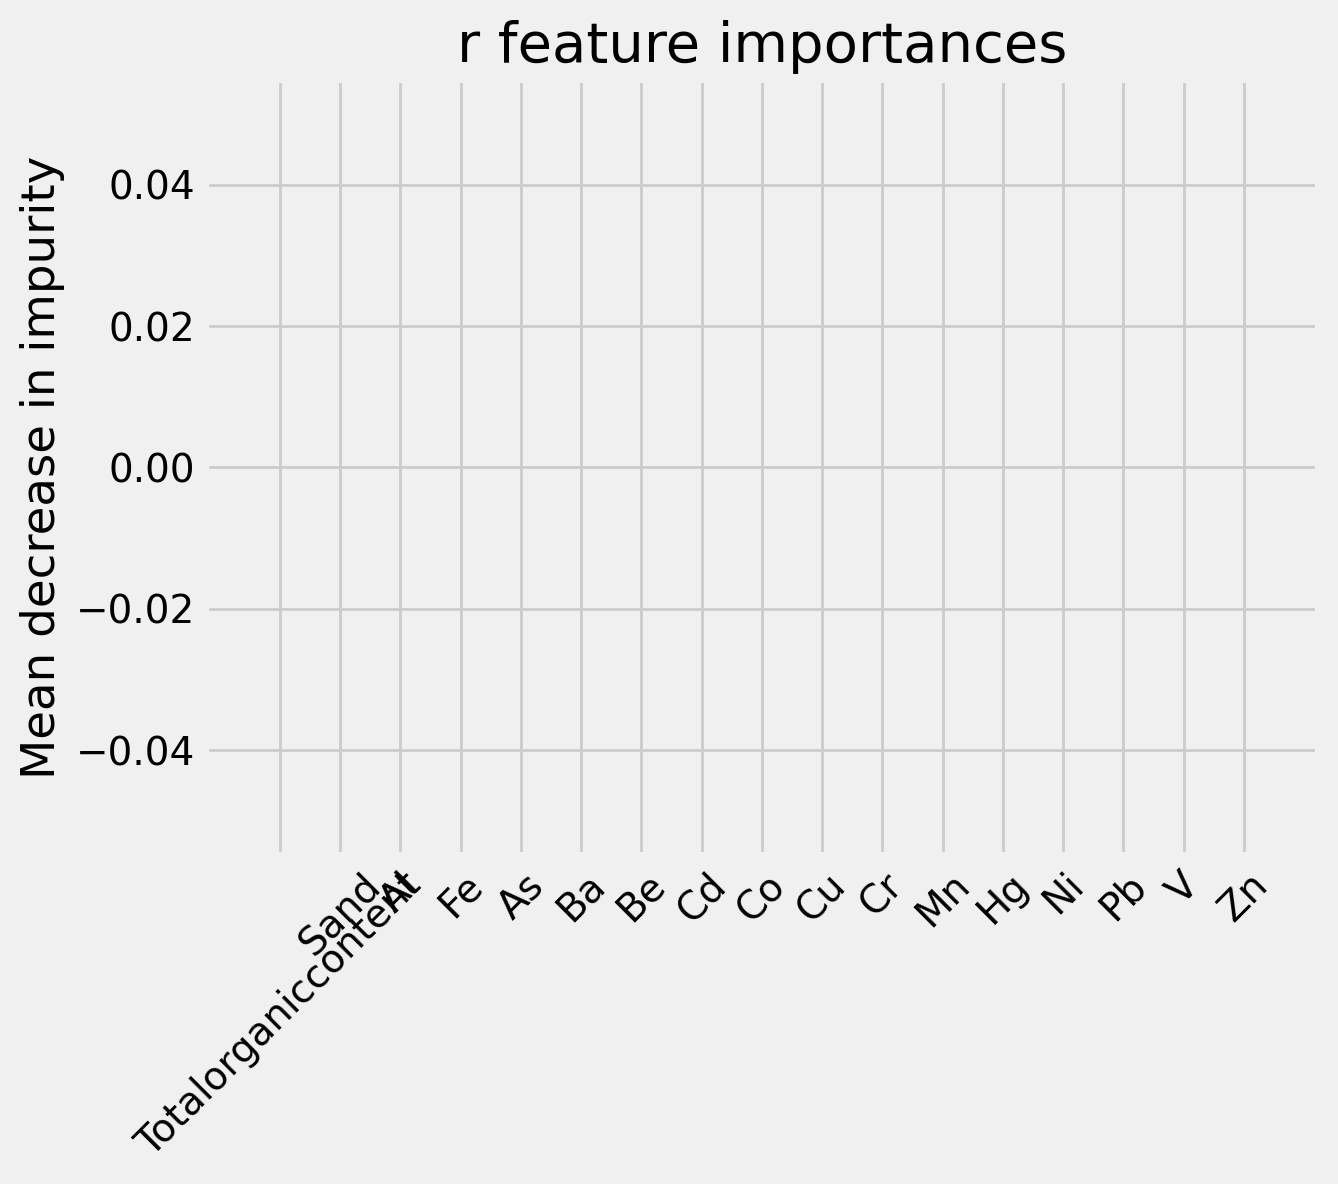

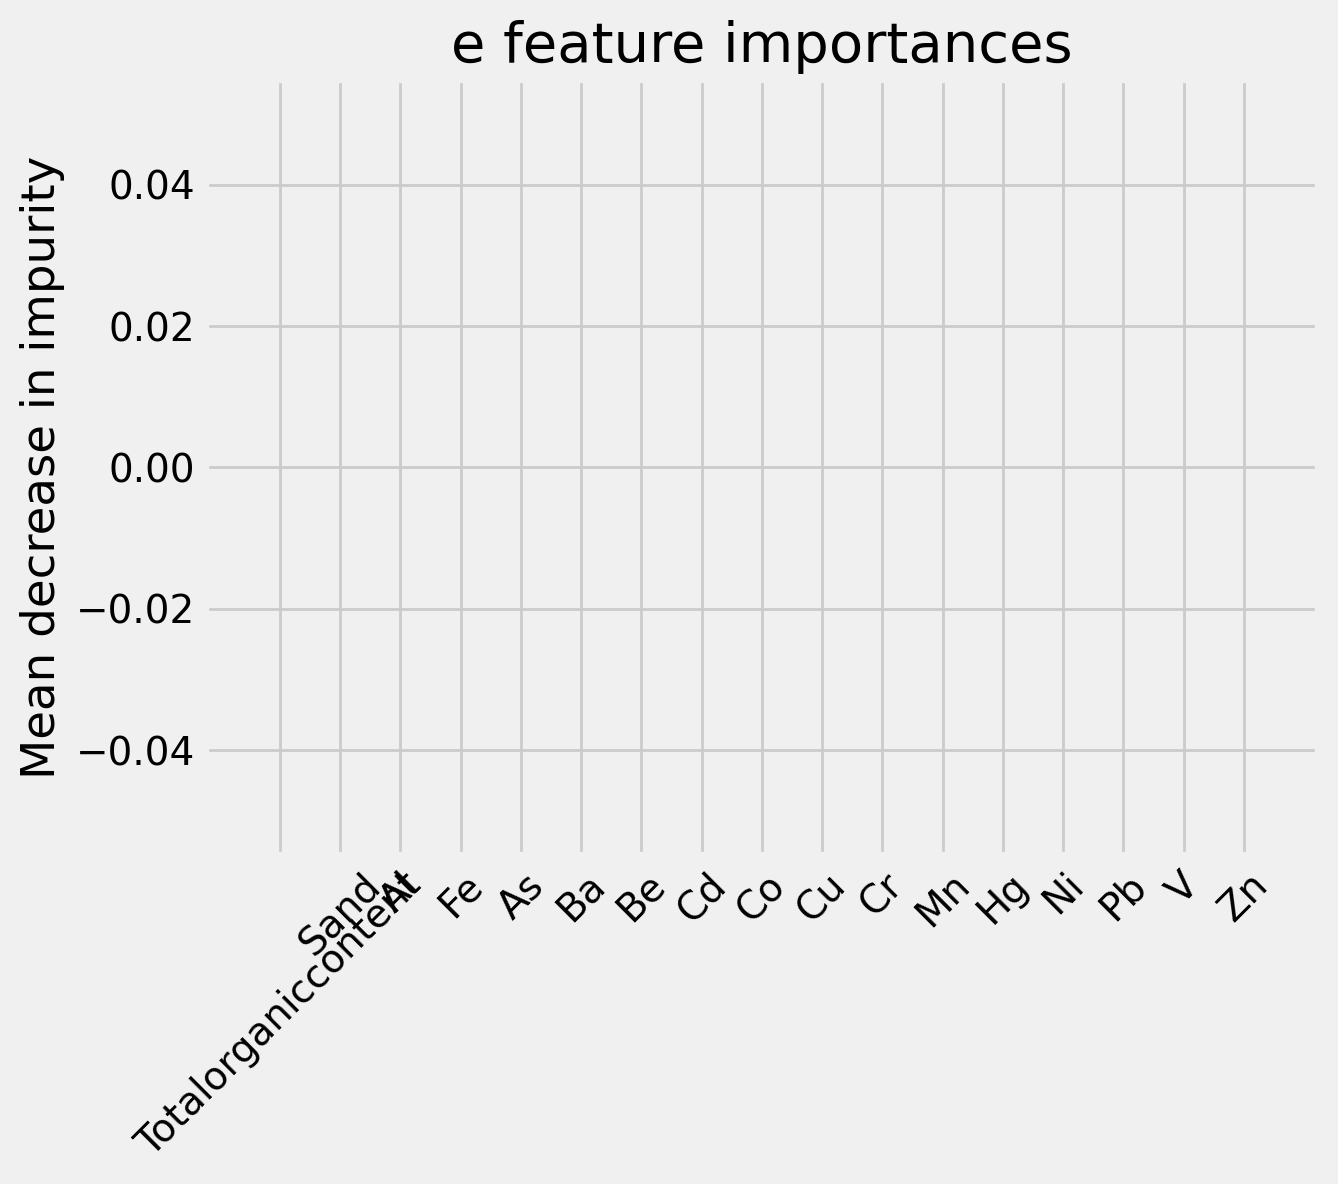

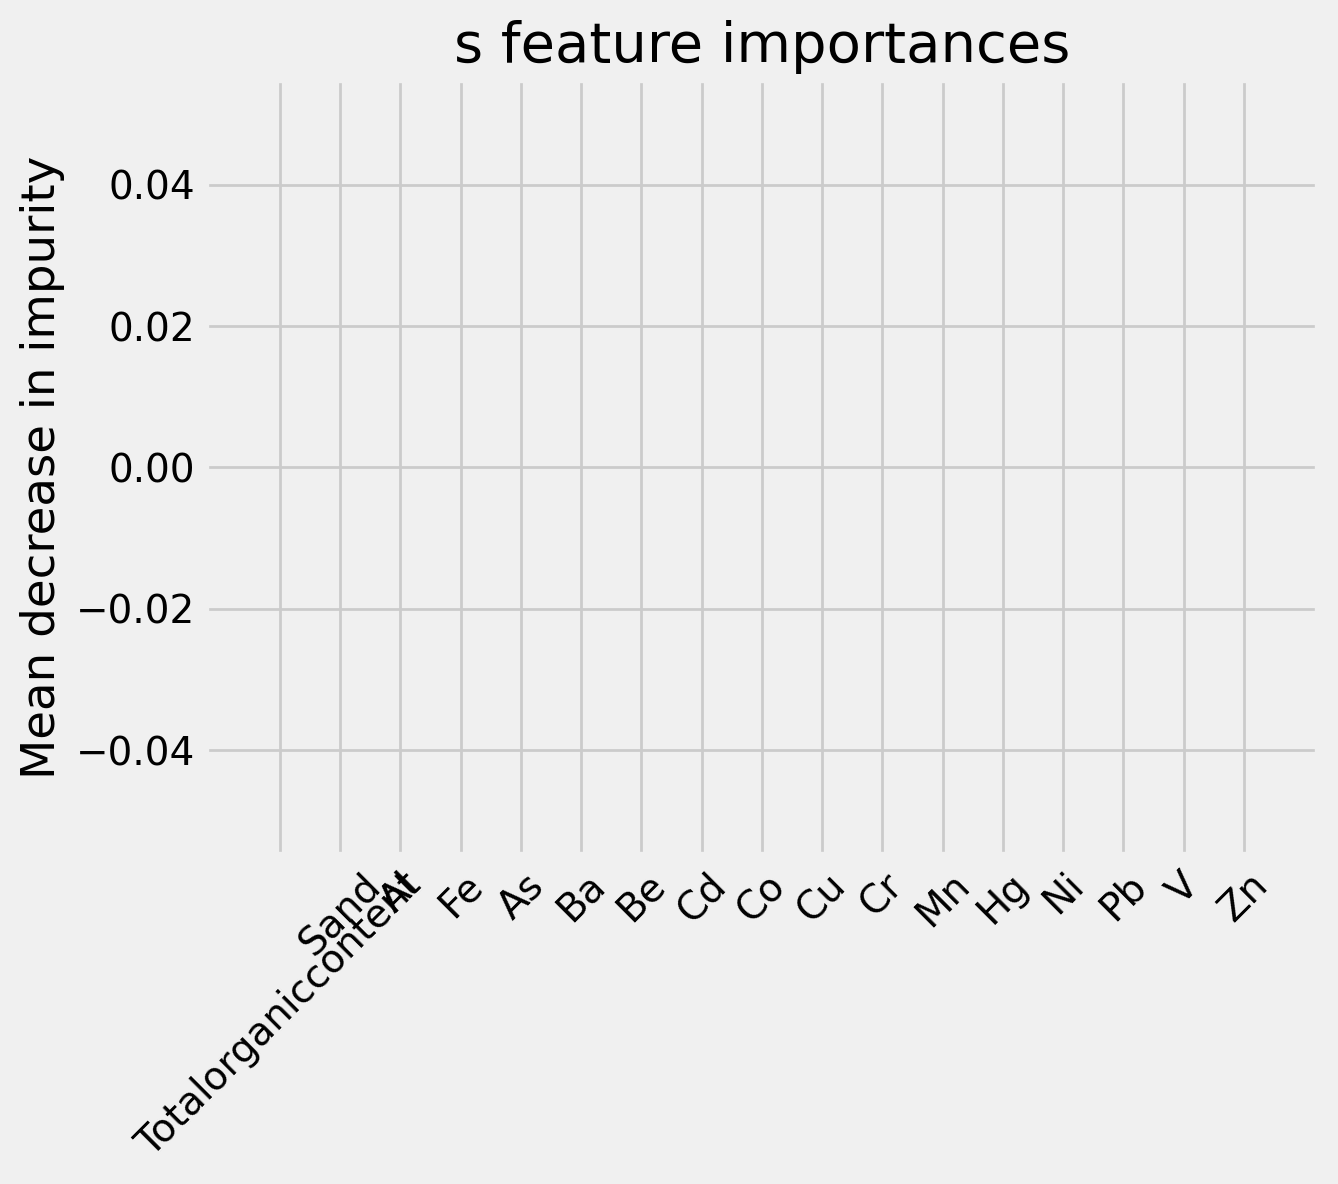

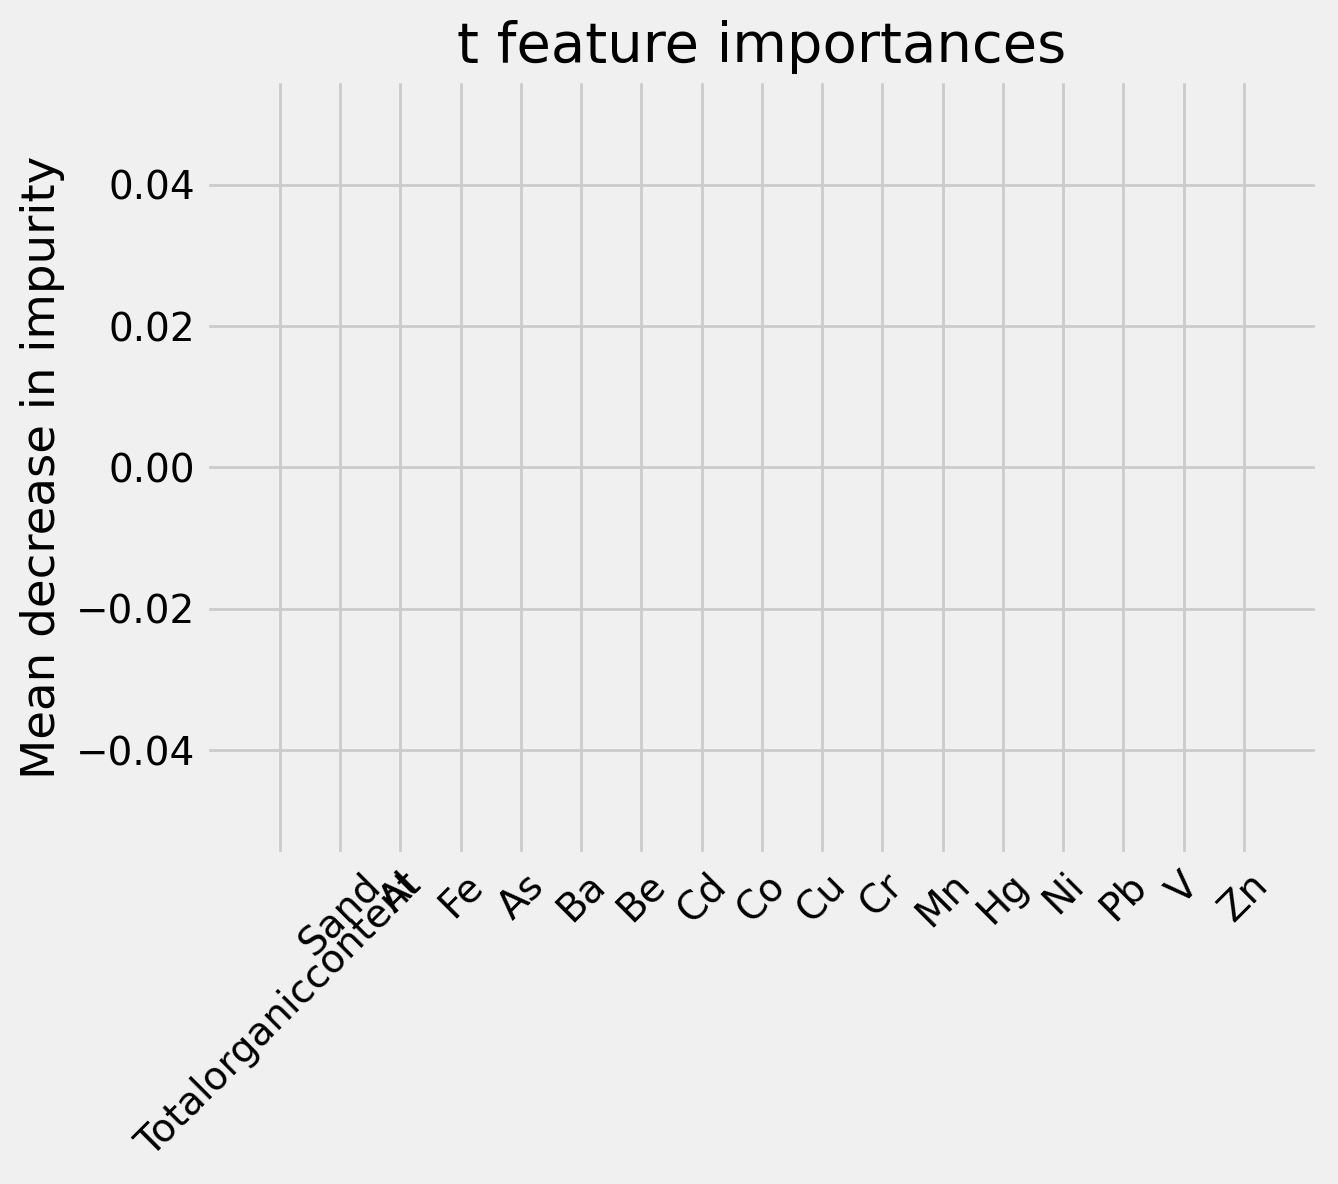

In [115]:
for name, model in zip(('Causal Forest'), (causal_forest)):

    imp = permutation_importance(model, X_test, y_test,
                                 n_repeats=50,
                                 random_state=0)

    fig, ax = plt.subplots()
    ax.set_title(f"{name} feature importances")
    ax.set_ylabel("Mean decrease in impurity")
    plt.bar(feature_names, imp['importances_mean'], yerr=imp['importances_std'])
    ax.set_xticklabels(feature_names, rotation=45)
    plt.show()

In [116]:
X_train.values.shape
y_train.shape

(280,)

In [117]:
tree_explainer = shap.TreeExplainer(causal_forest)
# Expected values for treatment=0 and treatment=1. i.e. Y|X,T=0 and Y|X,T=1
tree_explainer.expected_value
# background = shap.sample(X_train.values, 100)

# tree_explainer_t0 = shap.KernelExplainer(model=ctree.predict, data=background, treatment=0)
# tree_explainer_t1 = shap.KernelExplainer(model=ctree.predict, data=background, treatment=1)


# tree_explainer_t0.expected_value, tree_explainer_t1.expected_value



InvalidModelError: Model type not yet supported by TreeExplainer: <class 'causalml.inference.tree.causal.causalforest.CausalRandomForestRegressor'>

In [ ]:
# Tree Explainer for treatment=0
shap.initjs()
shap_values = tree_explainer.shap_values(observation)
shap.force_plot(tree_explainer.expected_value,
                shap_values,
                observation)

100%|██████████| 1/1 [00:00<00:00,  4.16it/s]


In [ ]:
forest_explainer = shap.KernelExplainer(model=ctree.predict, data=background)
shap_values = forest_explainer.shap_values(X_test.values)
forest_explainer.expected_value




100%|██████████| 400/400 [01:42<00:00,  3.91it/s]


0.638646879521519

In [ ]:
shap.initjs()
shap_values = forest_explainer.shap_values(observation)
shap.force_plot(forest_explainer.expected_value,
                shap_values,
                observation)

100%|██████████| 1/1 [00:00<00:00,  3.29it/s]
